In [ ]:
!pip install chromadb sentence-transformers

In [ ]:
!pip install psutil

In [ ]:
!pip install pandas

## Search, Retrieval, Merging, and Evaluation Functions

This notebook evaluates different embedding models for semantic search over the Ooredoo scraped chunks.

The search pipeline works as follows:

1. The user query is embedded using the same embedding function as the ChromaDB collection.
2. ChromaDB retrieves the most semantically similar chunks.
3. Retrieved chunks are grouped by page using metadata such as `content_hash`, `url`, `country`, and `chunk_type`.
4. If a page has multiple chunks, the first consecutive chunks are merged to produce a cleaner page-level result.
5. The final results are evaluated using Recall@K, Precision@K, NDCG@K, and latency.

For E5 models, the query uses the `query:` prefix and indexed documents use the `passage:` prefix.

In [1]:
import json
import chromadb

client = chromadb.PersistentClient(path="./new_db")
print("ChromaDB client initialized.")



ChromaDB client initialized.


In [ ]:
from chromadb.utils import embedding_functions

# Use a pre-built Sentence Transformer model for embeddings
# This model works well for general-purpose semantic search
sentence_transformer_ef = embedding_functions.SentenceTransformerEmbeddingFunction(model_name="Qwen/Qwen3-Embedding-0.6B",device="cuda")

# Create the collection, specifying the embedding function.
# If the collection already exists, use get_or_create_collection.
collection_name = "documents_collection"
try:
    client.delete_collection(name=collection_name) # Delete if exists from previous run
    client.delete_collection(name="collection_4b")
    print(f"Collection '{collection_name}' deleted.")
except:
    pass # Collection doesn't exist, ignore the error

collection = client.create_collection(
    name=collection_name,
    embedding_function=sentence_transformer_ef,
    metadata={"hnsw:space": "cosine"} # Specify cosine distance (common for text)
)

collection_qwen_4b = client.create_collection(
    name = "collection_4b",
    embedding_function = embedding_functions.SentenceTransformerEmbeddingFunction(model_name="Qwen/Qwen3-Embedding-4B",device="cuda"),
    metadata={"hnsw:space": "cosine"} # Specify cosine distance (common for text)
)


print(f"Collection '{collection.name}' created successfully.")

In [ ]:
import pandas as pd

path = r"C:\Users\USER\Desktop\pfe_26\data_chunking\semantic_chunks_generic_fixed.jsonl"

df = pd.read_json(path, lines=True)

def make_embedding_text(row):
    title = str(row.get("title", "")).strip()
    text = str(row.get("text", "")).strip()

    if title and title.lower() != "nan":
        return f"{title}  {text}"
    return text

df["text_to"] = df.apply(make_embedding_text, axis=1)

print (df["text_to"])


In [ ]:
!pip uninstall -y torch torchvision torchaudio
!pip cache purge
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [ ]:
# 2) install Python 3.12 + CUDA 12.1 wheels
!"{sys.executable}" -m pip install --no-cache-dir --force-reinstall --index-url https://download.pytorch.org/whl/cu121 torch==2.5.1+cu121 torchvision==0.20.1+cu121 torchaudio==2.5.1+cu121

In [ ]:
import torch, sys
print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

In [4]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:64"

import gc, torch
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [5]:
import time
import math
import gc
import torch
import pandas as pd
import chromadb
from chromadb.utils import embedding_functions
from tqdm.auto import tqdm

ids = df["chunk_id"].astype(str).tolist()
documents = df["text_to"].astype(str).tolist()

metadatas = (
    df[["url", "title", "section", "language"]]
    .fillna("")
    .astype(str)
    .to_dict("records")
)

# Safer for Qwen 0.6B on 6GB VRAM
batch_size = 4   # if stable try 8, if OOM keep 4 or 2
n = len(df)
num_batches = math.ceil(n / batch_size)
start_time = time.time()

print(f"Starting add: {n} chunks in {num_batches} batches (batch_size={batch_size})")

for b, i in enumerate(tqdm(range(0, n, batch_size), total=num_batches, desc="Adding to Chroma"), start=1):
    t0 = time.time()
    try:
        collection.add(
            ids=ids[i:i+batch_size],
            documents=documents[i:i+batch_size],
            metadatas=metadatas[i:i+batch_size],
        )
    except torch.cuda.OutOfMemoryError:
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        raise RuntimeError(f"OOM at batch {b}. Reduce batch_size to 2.")

    done = min(i + batch_size, n)
    elapsed = time.time() - start_time
    avg_per_batch = elapsed / b
    eta_sec = (num_batches - b) * avg_per_batch

    print(
        f"Batch {b}/{num_batches} done | "
        f"{done}/{n} rows | "
        f"batch_time={time.time()-t0:.2f}s | "
        f"elapsed={elapsed/60:.1f}m | ETA={eta_sec/60:.1f}m"
    )

    gc.collect()
    torch.cuda.empty_cache()

print(f"\nAdded {collection.count()} chunks in {(time.time()-start_time)/60:.2f} minutes.")

Starting add: 2008 chunks in 502 batches (batch_size=4)


Adding to Chroma:   0%|          | 0/502 [00:00<?, ?it/s]

Batch 1/502 done | 4/2008 rows | batch_time=3.38s | elapsed=0.1m | ETA=28.3m
Batch 2/502 done | 8/2008 rows | batch_time=2.22s | elapsed=0.1m | ETA=24.3m
Batch 3/502 done | 12/2008 rows | batch_time=0.23s | elapsed=0.1m | ETA=17.4m
Batch 4/502 done | 16/2008 rows | batch_time=2.08s | elapsed=0.1m | ETA=17.8m
Batch 5/502 done | 20/2008 rows | batch_time=1.04s | elapsed=0.2m | ETA=16.2m
Batch 6/502 done | 24/2008 rows | batch_time=1.90s | elapsed=0.2m | ETA=16.4m
Batch 7/502 done | 28/2008 rows | batch_time=0.23s | elapsed=0.2m | ETA=14.5m
Batch 8/502 done | 32/2008 rows | batch_time=1.67s | elapsed=0.2m | ETA=14.6m
Batch 9/502 done | 36/2008 rows | batch_time=0.20s | elapsed=0.2m | ETA=13.3m
Batch 10/502 done | 40/2008 rows | batch_time=1.08s | elapsed=0.3m | ETA=13.0m
Batch 11/502 done | 44/2008 rows | batch_time=7.47s | elapsed=0.4m | ETA=17.5m
Batch 12/502 done | 48/2008 rows | batch_time=0.73s | elapsed=0.4m | ETA=16.7m
Batch 13/502 done | 52/2008 rows | batch_time=0.99s | elapsed=0

In [6]:
import time, math, gc, torch
from tqdm.auto import tqdm

# for 4B on 6GB, start tiny
batch_size = 4   # maybe 2 if lucky, but 64 will OOM
n = len(df)
num_batches = math.ceil(n / batch_size)
start_time = time.time()

print(f"Starting add: {n} chunks in {num_batches} batches (batch_size={batch_size})")

for b, i in enumerate(tqdm(range(0, n, batch_size), total=num_batches, desc="Adding to Chroma"), start=1):
    t0 = time.time()

    try:
        collection_qwen_4b.add(
            ids=ids[i:i+batch_size],
            documents=documents[i:i+batch_size],
            metadatas=metadatas[i:i+batch_size],
        )
    except torch.cuda.OutOfMemoryError:
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        raise RuntimeError(f"OOM at batch {b}. Keep batch_size=1 or switch 4B to CPU.")

    done = min(i + batch_size, n)
    elapsed = time.time() - start_time
    eta_sec = (num_batches - b) * (elapsed / b)

    print(
        f"Batch {b}/{num_batches} done | "
        f"{done}/{n} rows | "
        f"batch_time={time.time()-t0:.2f}s | "
        f"elapsed={elapsed/60:.1f}m | ETA={eta_sec/60:.1f}m"
    )

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\nAdded {collection_qwen_4b.count()} chunks in {(time.time()-start_time)/60:.2f} minutes.")

Starting add: 2008 chunks in 502 batches (batch_size=4)


Adding to Chroma:   0%|          | 0/502 [00:00<?, ?it/s]

Batch 1/502 done | 4/2008 rows | batch_time=12.20s | elapsed=0.2m | ETA=102.0m
Batch 2/502 done | 8/2008 rows | batch_time=12.14s | elapsed=0.4m | ETA=102.4m
Batch 3/502 done | 12/2008 rows | batch_time=2.64s | elapsed=0.5m | ETA=76.0m
Batch 4/502 done | 16/2008 rows | batch_time=13.13s | elapsed=0.7m | ETA=84.6m
Batch 5/502 done | 20/2008 rows | batch_time=7.64s | elapsed=0.8m | ETA=80.5m
Batch 6/502 done | 24/2008 rows | batch_time=12.51s | elapsed=1.0m | ETA=84.5m
Batch 7/502 done | 28/2008 rows | batch_time=2.71s | elapsed=1.1m | ETA=75.7m
Batch 8/502 done | 32/2008 rows | batch_time=11.04s | elapsed=1.3m | ETA=77.7m
Batch 9/502 done | 36/2008 rows | batch_time=2.60s | elapsed=1.3m | ETA=71.4m
Batch 10/502 done | 40/2008 rows | batch_time=8.24s | elapsed=1.4m | ETA=71.1m
Batch 11/502 done | 44/2008 rows | batch_time=34.79s | elapsed=2.0m | ETA=90.5m
Batch 12/502 done | 48/2008 rows | batch_time=4.05s | elapsed=2.1m | ETA=85.8m
Batch 13/502 done | 52/2008 rows | batch_time=7.19s | e

In [7]:
# --- E5 setup + dataframe with passage prefix (new dataframe) ---
import pandas as pd
import chromadb
from chromadb.utils import embedding_functions


path = r"C:\Users\USER\Desktop\pfe_26\data_chunking\semantic_chunks_generic_fixed.jsonl"
df_e5 = pd.read_json(path, lines=True)

def make_embedding_text(row):
    title = str(row.get("title", "")).strip()
    text = str(row.get("text", "")).strip()
    if title and title.lower() != "nan":
        return f"{title}  {text}"
    return text


df_e5["text_to"] = df_e5.apply(make_embedding_text, axis=1)
df_e5["passage_text"] = "passage: " + df_e5["text_to"].astype(str)

# E5 embedding function
e5_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="intfloat/multilingual-e5-base",
)

# Create (or recreate) E5 collection
collection_name_e5 = "documents_collection_e5"
try:
    client.delete_collection(name=collection_name_e5)
except Exception:
    pass

collection_e5 = client.create_collection(
    name=collection_name_e5,
    embedding_function=e5_ef,
    metadata={"hnsw:space": "cosine"}
)

# Prepare payload
ids = df_e5["chunk_id"].astype(str).tolist()
documents = df_e5["passage_text"].astype(str).tolist()
metadatas = (
    df_e5[["url", "title", "section","page_type","language"]]
    .fillna("")
    .astype(str)
    .to_dict("records")
)

# Index
batch_size = 128
for i in range(0, len(df_e5), batch_size):
    collection_e5.add(
        ids=ids[i:i+batch_size],
        documents=documents[i:i+batch_size],
        metadatas=metadatas[i:i+batch_size],
    )
    print(f"Indexed {min(i+batch_size, len(df_e5))}/{len(df_e5)}")

print(f"E5 collection ready: {collection_e5.count()} chunks")
print(df_e5[["chunk_id", "text_to", "passage_text"]].head(3))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Indexed 128/2008
Indexed 256/2008
Indexed 384/2008
Indexed 512/2008
Indexed 640/2008
Indexed 768/2008
Indexed 896/2008
Indexed 1024/2008
Indexed 1152/2008
Indexed 1280/2008
Indexed 1408/2008
Indexed 1536/2008
Indexed 1664/2008
Indexed 1792/2008
Indexed 1920/2008
Indexed 2008/2008
E5 collection ready: 2008 chunks
                                            chunk_id  \
0  07dc23d400c62aa82908dfb02a5a60fc719ab2055eefff...   
1  4f3dfeffa3b578b978e7c6e7e377dec85b64063e52544e...   
2  bf45c188d32097f86d2b9ed126f88115272594462d6137...   

                                             text_to  \
0  Services  Vous avez un numéro non Ooredoo et v...   
1  Services  ge sera effectué dans un délai de 10...   
2  Services  er votre numéro de téléphone actuel ...   

                                        passage_text  
0  passage: Services  Vous avez un numéro non Oor...  
1  passage: Services  ge sera effectué dans un dé...  
2  passage: Services  er votre numéro de téléphon...  


In [ ]:
import pandas as pd
import chromadb
from chromadb.utils import embedding_functions

# =========================
# 1) Connect DB + collections
# =========================
client = chromadb.PersistentClient(path=r"C:\Users\USER\Desktop\pfe_26\embedding_gen\new_db")

qwen06_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="Qwen/Qwen3-Embedding-0.6B",
)
qwen4b_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="Qwen/Qwen3-Embedding-4B",
)
e5_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="intfloat/multilingual-e5-base",
)

# Replace names with your exact collection names
col_qwen06 = client.get_collection("documents_collection", embedding_function=qwen06_ef)
col_qwen4b = client.get_collection("collection_4b", embedding_function=qwen4b_ef)
col_e5     = client.get_collection("documents_collection_e5", embedding_function=e5_ef)

# =========================
# 2) 10 test queries + expected URLs (edit if needed)
# =========================
eval_set = [
    {"query": "roaming france", "expected_urls": ["https://www.ooredoo.tn/Business/fr/content/242-roaming", "https://www.ooredoo.tn/Personal/fr/content/133--roaming"]},
    {"query": "roaming qatar", "expected_urls": ["https://www.ooredoo.tn/Business/fr/content/242-roaming", "https://www.ooredoo.tn/Personal/fr/content/133--roaming"]},
    {"query": "comment activer le roaming", "expected_urls": ["https://www.ooredoo.tn/Personal/en/content/138-roaming-passeport", "https://www.ooredoo.tn/Business/fr/content/230-roaming-passeport"]},
    {"query": "portabilité numéro", "expected_urls": ["https://www.ooredoo.tn/Personal/fr/content/652-portabilite"]},
    {"query": "code RIO ooredoo", "expected_urls": ["https://www.ooredoo.tn/Personal/fr/content/652-portabilite"]},
    {"query": "oppo a3 prix", "expected_urls": ["https://www.ooredoo.tn/Personal/en/home/2043-oppo-a3-8256go.html"]},
    {"query": "offres internet business", "expected_urls": ["https://www.ooredoo.tn/Business/en/content/328-business-pro", "https://www.ooredoo.tn/Business/fr/content/292-business-progress"]},
    {"query": "forfait international pays arabes", "expected_urls": ["https://www.ooredoo.tn/Business/en/content/44-forfait-international-pays-arabes"]},
    {"query": "4g box internet", "expected_urls": ["https://www.ooredoo.tn/Personal/fr/content/349-4g-box-internet", "https://www.ooredoo.tn/Personal/en/content/349-4g-box-internet"]},
    {"query": "office in a box fixed voice", "expected_urls": ["https://www.ooredoo.tn/Business/en/content/401-office-in-a-box", "https://www.ooredoo.tn/Business/fr/content/401-office-in-a-box"]},
]

# =========================
# 3) Metrics
# =========================
def recall_at_k(returned_urls, expected_urls, k=5):
    return 1.0 if any(u in returned_urls[:k] for u in expected_urls) else 0.0

def mrr_at_k(returned_urls, expected_urls, k=5):
    for rank, u in enumerate(returned_urls[:k], start=1):
        if u in expected_urls:
            return 1.0 / rank
    return 0.0

def evaluate_collection(collection, name, eval_rows, k=5, use_e5_prefix=False):
    rows = []
    for row in eval_rows:
        q = row["query"]
        q_text = f"query: {q}" if use_e5_prefix else q

        res = collection.query(
            query_texts=[q_text],
            n_results=k,
            include=["metadatas", "distances"]
        )
        urls = [m.get("url", "") for m in res["metadatas"][0]]

        rows.append({
            "model": name,
            "query": q,
            f"recall@{k}": recall_at_k(urls, row["expected_urls"], k),
            f"mrr@{k}": mrr_at_k(urls, row["expected_urls"], k),
            "top1_url": urls[0] if urls else "",
            "top_urls": urls
        })

    df_res = pd.DataFrame(rows)
    summary = {
        "model": name,
        f"mean_recall@{k}": df_res[f"recall@{k}"].mean(),
        f"mean_mrr@{k}": df_res[f"mrr@{k}"].mean(),
    }
    return df_res, summary

# =========================
# 4) Run benchmark
# =========================
k = 5

df_q06, s_q06 = evaluate_collection(col_qwen06, "qwen_0.6b", eval_set, k=k, use_e5_prefix=False)
df_q4b, s_q4b = evaluate_collection(col_qwen4b, "qwen_4b",   eval_set, k=k, use_e5_prefix=False)
df_e5,  s_e5  = evaluate_collection(col_e5,     "e5_base",   eval_set, k=k, use_e5_prefix=True)

summary_df = pd.DataFrame([s_q06, s_q4b, s_e5]).sort_values(by=f"mean_mrr@{k}", ascending=False)
details_df = pd.concat([df_q06, df_q4b, df_e5], ignore_index=True)

print("=== BENCHMARK SUMMARY ===")
display(summary_df)

print("\n=== PER-QUERY DETAILS ===")
display(details_df[["model", "query", f"recall@{k}", f"mrr@{k}", "top1_url"]])

# Optional: save results
summary_df.to_csv("benchmark_summary.csv", index=False)
details_df.to_csv("benchmark_details.csv", index=False)

In [12]:
# CPU-only latency + memory benchmark for your 3 collections

import time
import statistics
import psutil
import pandas as pd
import chromadb
from chromadb.utils import embedding_functions

DB_PATH = r"C:\Users\USER\Desktop\pfe_26\embedding_gen\new_db"  # adjust if needed
client = chromadb.PersistentClient(path=DB_PATH)

# CPU embedding functions (force cpu for fair comparison)
qwen06_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="Qwen/Qwen3-Embedding-0.6B",
    device="cpu"
)
qwen4b_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="Qwen/Qwen3-Embedding-4B",
    device="cpu"
)
e5_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="intfloat/multilingual-e5-base",
    device="cpu"
)

# Use your real collection names
col_qwen06 = client.get_collection("documents_collection", embedding_function=qwen06_ef)
col_qwen4b = client.get_collection("collection_4b", embedding_function=qwen4b_ef)
col_e5     = client.get_collection("documents_collection_e5", embedding_function=e5_ef)

test_queries = [
    "roaming france",
    "roaming qatar",
    "comment activer le roaming",
    "portabilité numéro",
    "code RIO",
    "offres internet business",
    "prix oppo a3",
    "4g box internet",
    "forfait international pays arabes",
    "service client ooredoo",
]

models = [
    {"name": "qwen_0.6b", "collection": col_qwen06, "use_e5_prefix": False},
    {"name": "qwen_4b",   "collection": col_qwen4b, "use_e5_prefix": False},
    {"name": "e5_base",   "collection": col_e5,     "use_e5_prefix": True},
]

proc = psutil.Process()

def p95(values):
    v = sorted(values)
    idx = max(0, int(round(0.95 * len(v))) - 1)
    return v[idx]

def benchmark_model(model_cfg, n_results=5, warmup=2):
    col = model_cfg["collection"]
    use_e5_prefix = model_cfg["use_e5_prefix"]

    # warmup
    for i in range(min(warmup, len(test_queries))):
        q = f"query: {test_queries[i]}" if use_e5_prefix else test_queries[i]
        _ = col.query(query_texts=[q], n_results=n_results, include=["distances"])

    lat_ms = []
    rss_mb = []

    for q0 in test_queries:
        q = f"query: {q0}" if use_e5_prefix else q0

        t0 = time.perf_counter()
        _ = col.query(query_texts=[q], n_results=n_results, include=["distances", "metadatas"])
        dt = (time.perf_counter() - t0) * 1000.0

        lat_ms.append(dt)

    return {
        "model": model_cfg["name"],
        "queries": len(test_queries),
        "latency_mean_ms": round(statistics.mean(lat_ms), 2),
        "latency_p50_ms": round(statistics.median(lat_ms), 2),
        "latency_p95_ms": round(p95(lat_ms), 2),
        "latency_max_ms": round(max(lat_ms), 2),
    }

rows = [benchmark_model(m) for m in models]
results_df = pd.DataFrame(rows).sort_values("latency_mean_ms")

print("CPU-only benchmark:")
display(results_df)

CPU-only benchmark:


,model,queries,latency_mean_ms,latency_p50_ms,latency_p95_ms,latency_max_ms,rss_mean_mb,rss_max_mb
2,e5_base,10,105.02,103.84,138.96,138.96,449.48,451.74
0,qwen_0.6b,10,119.04,127.16,150.55,150.55,86.07,89.00
1,qwen_4b,10,651.33,655.81,681.93,681.93,107.62,113.17


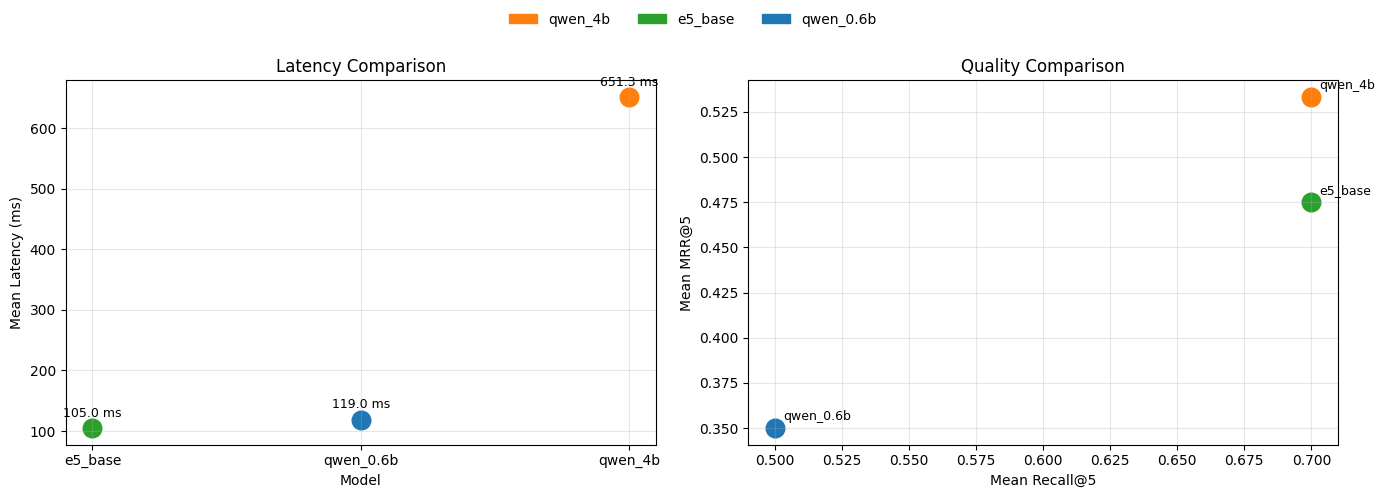

In [16]:
# Combined plots (latency-only + recall/mrr) with one color per model

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# 1) Build quality_df from your summary_df
quality_df = summary_df.rename(columns={
    "mean_recall@5": "mean_recall",
    "mean_mrr@5": "mean_mrr"
})[["model", "mean_recall", "mean_mrr"]].copy()

# 2) Build latency_df from your results_df
latency_df = results_df[["model", "latency_mean_ms"]].copy()

# 3) Merge for plotting
plot_df = pd.merge(quality_df, latency_df, on="model", how="inner")

# 4) Fixed colors per model
color_map = {
    "qwen_0.6b": "#1f77b4",  # blue
    "qwen_4b":   "#ff7f0e",  # orange
    "e5_base":   "#2ca02c",  # green
}

# fallback color for unexpected model names
for m in plot_df["model"].unique():
    if m not in color_map:
        color_map[m] = "#7f7f7f"

# 5) Create combined figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Left: latency-only
ax = axes[0]
lat_sorted = plot_df.sort_values("latency_mean_ms")
for _, r in lat_sorted.iterrows():
    c = color_map[r["model"]]
    ax.scatter(r["model"], r["latency_mean_ms"], s=180, color=c)
    ax.annotate(
        f'{r["latency_mean_ms"]:.1f} ms',
        (r["model"], r["latency_mean_ms"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

ax.set_title("Latency Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Mean Latency (ms)")
ax.grid(True, alpha=0.3)

# ---- Right: quality (Recall vs MRR)
ax = axes[1]
for _, r in plot_df.iterrows():
    c = color_map[r["model"]]
    ax.scatter(r["mean_recall"], r["mean_mrr"], s=180, color=c)
    ax.annotate(
        r["model"],
        (r["mean_recall"], r["mean_mrr"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

ax.set_title("Quality Comparison")
ax.set_xlabel("Mean Recall@5")
ax.set_ylabel("Mean MRR@5")
ax.grid(True, alpha=0.3)

# shared legend
handles = [mpatches.Patch(color=color_map[m], label=m) for m in plot_df["model"].unique()]
fig.legend(handles=handles, loc="upper center", ncol=len(handles), frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

In [15]:
import pandas as pd
import chromadb
from chromadb.utils import embedding_functions

# -------------------------
# 1) Load data
# -------------------------
path = r"C:\Users\USER\Desktop\pfe_26\data_chunking\semantic_chunks_generic_fixed.jsonl"
df = pd.read_json(path, lines=True)

def make_embedding_text(row):
    title = str(row.get("title", "")).strip()
    text = str(row.get("text", "")).strip()
    return f"{title}  {text}" if title and title.lower() != "nan" else text

df["text_to"] = df.apply(make_embedding_text, axis=1)

# E5 requires passage/query style
df["text_to_e5"] = "passage: " + df["text_to"].astype(str)

# -------------------------
# 2) Build payload
# -------------------------
ids = df["chunk_id"].astype(str).tolist()
documents = df["text_to_e5"].astype(str).tolist()

# Add needed metadata for page-level grouping
metadatas = (
    df[["url", "title", "section", "language", "chunk_index", "content_hash"]]
    .fillna("")
    .assign(chunk_index=lambda x: x["chunk_index"].astype(int))
    .astype({
        "url": "str",
        "title": "str",
        "section": "str",
        "language": "str",
        "content_hash": "str",
    })
    .to_dict("records")
)

# -------------------------
# 3) Connect DB + create collection
# -------------------------
COLLECTION_NAME = "new_e5_collection"


e5_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="intfloat/multilingual-e5-base",
)


try:
    client.delete_collection(name=COLLECTION_NAME)
except Exception:
    pass

collection = client.create_collection(
    name=COLLECTION_NAME,
    embedding_function=e5_ef,
    metadata={"hnsw:space": "cosine"}
)

# -------------------------
# 4) Index
# -------------------------
batch_size = 128
for i in range(0, len(df), batch_size):
    collection.add(
        ids=ids[i:i+batch_size],
        documents=documents[i:i+batch_size],
        metadatas=metadatas[i:i+batch_size],
    )
    print(f"Indexed {min(i+batch_size, len(df))}/{len(df)}")

print(f"Done. Collection '{COLLECTION_NAME}' count = {collection.count()}")


Indexed 128/2008
Indexed 256/2008
Indexed 384/2008
Indexed 512/2008
Indexed 640/2008
Indexed 768/2008
Indexed 896/2008
Indexed 1024/2008
Indexed 1152/2008
Indexed 1280/2008
Indexed 1408/2008
Indexed 1536/2008
Indexed 1664/2008
Indexed 1792/2008
Indexed 1920/2008
Indexed 2008/2008
Done. Collection 'new_e5_collection' count = 2008


In [7]:
import chromadb
from collections import defaultdict

# =========================
# 2) Merge helpers
# =========================
collection = client.get_collection(name="new_e5_collection")
def merge_text_keep_first_passage(chunks_in_order):
    """
    Keep 'passage:' only in the first chunk (if present),
    remove it from subsequent chunks before merging.
    """
    merged_parts = []
    for i, text in enumerate(chunks_in_order):
        s = (text or "").strip()
        if i > 0 and s.lower().startswith("passage:"):
            s = s[len("passage:"):].strip()
        merged_parts.append(s)
    return " ".join(p for p in merged_parts if p).strip()

def build_page_result(hits):
    """
    hits: list of tuples (meta, doc, dist)
    """
    hits_sorted = sorted(hits, key=lambda x: int(x[0].get("chunk_index", 0)))
    best_dist = min(h[2] for h in hits_sorted)

    chunk_texts = [h[1] for h in hits_sorted]
    merged_text = merge_text_keep_first_passage(chunk_texts)

    m0 = hits_sorted[0][0]
    return {
        "url": m0.get("url", ""),
        "title": m0.get("title", ""),
        "section": m0.get("section", ""),
        "language": m0.get("language", ""),
        "content_hash": m0.get("content_hash", ""),
        "best_distance": best_dist,
        "matched_chunks": len(hits_sorted),
        "chunk_indexes": [int(h[0].get("chunk_index", 0)) for h in hits_sorted],
        "text": merged_text
    }

# =========================
# 3) Page-level search
# =========================
def search_pages(
    query,
    n_results_chunks=30,
    top_pages=5,
    where=None
):
    # E5 query prefix
    q = f"query: {query}"

    kwargs = {
        "query_texts": [q],
        "n_results": n_results_chunks,
        "include": ["documents", "metadatas", "distances"]
    }
    if where is not None:
        kwargs["where"] = where

    res = collection.query(**kwargs)

    docs = res["documents"][0]
    metas = res["metadatas"][0]
    dists = res["distances"][0]

    # Group by page (content_hash preferred)
    grouped = defaultdict(list)
    for doc, meta, dist in zip(docs, metas, dists):
        page_key = meta.get("content_hash") or meta.get("url")
        grouped[page_key].append((meta, doc, dist))

    # Build one result per page
    page_results = [build_page_result(hits) for hits in grouped.values()]
    page_results.sort(key=lambda x: x["best_distance"])  # lower distance = better
    return page_results[:top_pages]

# =========================
# 4) Test on problematic queries
# =========================
test_queries = [
    "portabilité numéro",
     "oppo phones",
     "fibre pro",
     "roaming orange",
]

for q in test_queries:
    print(f"\n=== Query: {q} ===")
    results = search_pages(
        query=q,
        n_results_chunks=100,  # retrieve enough chunks before grouping
        top_pages=5
    )

    for i, r in enumerate(results, 1):
        print(f"{i}. dist={r['best_distance']:.4f} | chunks={r['matched_chunks']} | idx={r['chunk_indexes']}")
        print(f"   title: {r['title']}")
        print(f"   url:   {r['url']}")
        print(f"   text:  {r['text'][:300]}...\n")


# =========================
# 5) Example with metadata pre-filter
# =========================
# personal_results = search_pages("roaming qatar", where={"section": "personal"})
# business_results = search_pages("roaming qatar", where={"section": "business"})


=== Query: portabilité numéro ===
1. dist=0.1292 | chunks=3 | idx=[0, 1, 2]
   title: Services
   url:   https://www.ooredoo.tn/Personal/fr/content/652-portabilite
   text:  passage: Services  Vous avez un numéro non Ooredoo et vous souhaitez profiter de nos offres et services? La portabilité de numéro vous permet de changer d’opérateur tout en conservant votre numéro! • La portabilité vous permet de conserver votre numéro de téléphone actuel tout en profitant des nombr...

2. dist=0.1535 | chunks=2 | idx=[0, 1]
   title: Services
   url:   https://www.ooredoo.tn/Personal/en/content/652-portabilite
   text:  passage: Services  Do you have a non-Ooredoo number and want to take advantage of our offers and services? The portability allows you to switch operators while keeping your current number! • Portability enables you to retain your current phone number while enjoying the numerous benefits offered by O...

3. dist=0.1688 | chunks=1 | idx=[0]
   title: Services+
   url:   https://www.

In [8]:
import pandas as pd
import chromadb
from chromadb.utils import embedding_functions

# -------------------------
# 1) Load data
# -------------------------
path = r"C:\Users\USER\Desktop\pfe_26\data_chunking\semantic_chunks_generic_fixed.jsonl"
df = pd.read_json(path, lines=True)

def make_embedding_text(row):
    title = str(row.get("title", "")).strip()
    text = str(row.get("text", "")).strip()
    return f"{title}  {text}" if title and title.lower() != "nan" else text

df["text_to"] = df.apply(make_embedding_text, axis=1)
df["text_to_e5"] = "passage: " + df["text_to"].astype(str)

# -------------------------
# 2) Build payload
# -------------------------
ids = df["chunk_id"].astype(str).tolist()
documents = df["text_to_e5"].astype(str).tolist()

def build_metadata(row):
    return {
        "url":          str(row.get("url", "") or ""),
        "title":        str(row.get("title", "") or ""),
        "section":      str(row.get("section", "") or ""),
        "language":     str(row.get("language", "") or ""),
        "chunk_index":  int(row.get("chunk_index", 0) or 0),
        "content_hash": str(row.get("content_hash", "") or ""),
        "chunk_type":   str(row.get("chunk_type", "") or ""),
        "country":      str(row.get("country", "") or ""),  # "" for non-roaming
        "zone":         str(row.get("zone", "") or ""),     # "" for non-roaming
    }

metadatas = [build_metadata(row) for _, row in df.iterrows()]

# -------------------------
# 3) Quick sanity check before indexing
# -------------------------
roaming_sample = df[df["country"].notna() & (df["country"] != "")]
print(f"Total chunks: {len(df)}")
print(f"Chunks with country: {len(roaming_sample)}")
print(f"Sample countries: {roaming_sample['country'].unique()[:10]}")
print(f"Sample chunk_types: {df['chunk_type'].value_counts().head(10)}")

# -------------------------
# 4) Connect DB + create NEW collection
# -------------------------
COLLECTION_NAME = "e5_collection_v2"

e5_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="intfloat/multilingual-e5-base",
)

try:
    client.delete_collection(name=COLLECTION_NAME)
    print(f"Deleted existing '{COLLECTION_NAME}'")
except Exception:
    pass

collection = client.create_collection(
    name=COLLECTION_NAME,
    embedding_function=e5_ef,
    metadata={"hnsw:space": "cosine"}
)

# -------------------------
# 5) Index
# -------------------------
batch_size = 128
for i in range(0, len(df), batch_size):
    collection.add(
        ids=ids[i:i+batch_size],
        documents=documents[i:i+batch_size],
        metadatas=metadatas[i:i+batch_size],
    )
    print(f"Indexed {min(i+batch_size, len(df))}/{len(df)}")

print(f"Done. Collection '{COLLECTION_NAME}' count = {collection.count()}")

# -------------------------
# 6) Verify metadata on a roaming chunk
# -------------------------
sample = collection.get(
    where={"country": roaming_sample["country"].iloc[0]},
    limit=1,
    include=["metadatas"]
)
print("\nSample roaming chunk metadata:")
print(sample["metadatas"][0])

Total chunks: 2008
Chunks with country: 674
Sample countries: ['Afghanistan' 'Afrique du sud' 'Albanie' 'Algérie' 'Allemagne' 'Andorre'
 'Angola' 'Arabie Saoudite' 'Argentine' 'Arménie']
Sample chunk_types: chunk_type
default                      540
roaming_partner_operators    366
roaming_tariff_country       308
product_specs                206
category_nav                 155
pricing                      147
activation                   117
listing_overview             108
shop_info                     46
faq                           10
Name: count, dtype: int64
Indexed 128/2008
Indexed 256/2008
Indexed 384/2008
Indexed 512/2008
Indexed 640/2008
Indexed 768/2008
Indexed 896/2008
Indexed 1024/2008
Indexed 1152/2008
Indexed 1280/2008
Indexed 1408/2008
Indexed 1536/2008
Indexed 1664/2008
Indexed 1792/2008
Indexed 1920/2008
Indexed 2008/2008
Done. Collection 'e5_collection_v2' count = 2008

Sample roaming chunk metadata:
{'language': 'fr', 'zone': 'ZONE 7', 'chunk_type': 'roaming_tari

In [4]:
import pandas as pd
import time

# -------------------------
# 7) Eval set with expected URLs
# -------------------------
eval_set = [
    {
        "query": "roaming qatar",
        "expected_urls": [
            "https://www.ooredoo.tn/Business/fr/content/242-roaming",
            "https://www.ooredoo.tn/Personal/fr/content/133--roaming",
        ],
    },
    {
        "query": "roaming france",
        "expected_urls": [
            "https://www.ooredoo.tn/Business/fr/content/242-roaming",
            "https://www.ooredoo.tn/Personal/fr/content/133--roaming",
        ],
    },
    {
        "query": "roaming offres",
        "expected_urls": [
            "https://www.ooredoo.tn/Business/fr/content/230-roaming-passeport",
            "https://www.ooredoo.tn/Personal/en/content/138-roaming-passeport",
        ],
    },
    {
        "query": "portabilité numéro",
        "expected_urls": [
            "https://www.ooredoo.tn/Personal/fr/content/652-portabilite",
        ],
    },
    {
        "query": "oppo a3",
        "expected_urls": [
            "https://www.ooredoo.tn/Personal/fr/accueil/2043-oppo-a3-8256go.html",
            "https://www.ooredoo.tn/Personal/en/home/2023-smartphone-oppo-a3-6128go.html",
        ],
    },
]

# -------------------------
# 8) Metrics
# -------------------------
def recall_at_k(returned_urls, expected_urls, k=5):
    ret = set(returned_urls[:k])      # dedup by URL
    exp = set(expected_urls)
    hits = len(ret & exp)
    return hits / len(exp) if exp else 0.0

def precision_at_k(returned_urls, expected_urls, k=5):
    ret = set(returned_urls[:k])      # dedup by URL
    exp = set(expected_urls)
    hits = len(ret & exp)
    return hits / k

# -------------------------
# 9) Run benchmark
# -------------------------
K = 5
rows = []

for item in eval_set:
    q = item["query"]

    t0 = time.perf_counter()
    pages = search_pages(query=q, n_results_chunks=100, top_pages=K)
    latency_ms = (time.perf_counter() - t0) * 1000

    returned_urls = [p["url"] for p in pages]

    rows.append({
        "query": q,
        f"recall@{K}": recall_at_k(returned_urls, item["expected_urls"], K),
        f"precision@{K}": precision_at_k(returned_urls, item["expected_urls"], K),
        "latency_ms": latency_ms,
        "top_urls": returned_urls,
    })

details_df = pd.DataFrame(rows)
summary_df = pd.DataFrame([{
    "collection": "e5_collection_v2",
    f"mean_recall@{K}": details_df[f"recall@{K}"].mean(),
    f"mean_precision@{K}": details_df[f"precision@{K}"].mean(),
    "mean_latency_ms": details_df["latency_ms"].mean(),
    "p95_latency_ms": details_df["latency_ms"].quantile(0.95),
}])

print("=== SUMMARY ===")
display(summary_df)

print("=== DETAILS ===")
display(details_df[["query", f"recall@{K}", f"precision@{K}", "latency_ms", "top_urls"]])


=== SUMMARY ===


,collection,mean_recall@5,mean_precision@5,mean_latency_ms,p95_latency_ms
0,e5_collection_v2,1.0,0.36,161.65864,185.29436


=== DETAILS ===


,query,recall@5,precision@5,latency_ms,top_urls
0,roaming qatar,1.0,0.4,134.1079,[https://www.ooredoo.tn/Personal/fr/content/13...
1,roaming france,1.0,0.4,188.2255,[https://www.ooredoo.tn/Business/fr/content/24...
2,roaming offres,1.0,0.4,173.5698,[https://www.ooredoo.tn/Business/fr/content/23...
3,portabilité numéro,1.0,0.2,144.6576,[https://www.ooredoo.tn/Personal/fr/content/65...
4,oppo a3,1.0,0.4,167.7324,[https://www.ooredoo.tn/Personal/en/home/2023-...


In [4]:
from sentence_transformers import CrossEncoder

# Multilingual reranker
reranker = CrossEncoder(
    "BAAI/bge-reranker-v2-m3",
)

def search_pages_with_rerank(
    query,
    n_results_chunks=30,
    candidate_pages=10,
    top_pages=5
):
    # Your existing logic:
    # - retrieves chunks
    # - groups by page/content_hash/url
    # - merges chunks
    # - keeps unique url/title/text
    candidate_results = search_pages(
        query=query,
        n_results_chunks=n_results_chunks,
        top_pages=candidate_pages
    )

    if not candidate_results:
        return []

    # Rerank already-merged page-level results
    pairs = []
    for r in candidate_results:
        title = r.get("title", "")
        text = r.get("text", "")
        url = r.get("url", "")

        # Give reranker title + URL + merged text
        pairs.append([query, f"{title}\n{url}\n{text}"])

    scores = reranker.predict(pairs)

    reranked_results = []
    for r, score in zip(candidate_results, scores):
        r = dict(r)
        r["rerank_score"] = float(score)
        reranked_results.append(r)

    # Higher rerank score = more relevant
    reranked_results.sort(key=lambda x: x["rerank_score"], reverse=True)

    return reranked_results[:top_pages]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

In [ ]:
# =========================
# 6) Test queries
# =========================
test_queries = [
    "roaming qatar",
    "roaming france",
    "roaming orange",
    "roaming offres",
    "portabilité numéro",
    "fibre",
]

for q in test_queries:
    print(f"\n=== Query: {q} ===")
    results = search_pages(query=q, n_results_chunks=100, top_pages=5)
    for i, r in enumerate(results, 1):
        print(f"{i}. dist={r['best_distance']:.4f} | country={r['country']} | chunks={r['matched_chunks']} | idx={r['chunk_indexes']}")
        print(f"   title:      {r['title']}")
        print(f"   url:        {r['url']}")
        print(f"   chunk_type: {r['chunk_type']}")
        print(f"   text:       {r['text'][:200]}...\n")

In [11]:
import math
import time
import re
import torch
import pandas as pd
import chromadb
from collections import defaultdict
from chromadb.utils import embedding_functions

# =========================
# 1) Config
# =========================
DB_PATH = r"C:\Users\USER\Desktop\pfe_26\embedding_gen\new_db"

QWEN06_COLLECTION = "documents_collection"
QWEN4B_COLLECTION = "collection_4b"
E5_COLLECTION = "new_e5_collection"  # change to "e5_collection_v2" if that is your latest collection

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# 2) Connect to collections
# =========================
client = chromadb.PersistentClient(path=DB_PATH)

qwen06_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="Qwen/Qwen3-Embedding-0.6B",
    device=DEVICE,
)

qwen4b_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="Qwen/Qwen3-Embedding-4B",
    device=DEVICE,
)

e5_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="intfloat/multilingual-e5-base",
    device=DEVICE,
)

collection_qwen06 = client.get_collection(
    name=QWEN06_COLLECTION,
    embedding_function=qwen06_ef,
)

collection_qwen4b = client.get_collection(
    name=QWEN4B_COLLECTION,
    embedding_function=qwen4b_ef,
)

collection_e5 = client.get_collection(
    name=E5_COLLECTION,
    embedding_function=e5_ef,
)

# =========================
# 3) Eval set
# =========================
eval_set = [
    # Roaming
    {
        "query": "roaming france",
        "expected_urls": [
            "https://www.ooredoo.tn/Business/fr/content/242-roaming",
            "https://www.ooredoo.tn/Personal/fr/content/133--roaming",
        ],
    },
    {
        "query": "roaming qatar",
        "expected_urls": [
            "https://www.ooredoo.tn/Business/fr/content/242-roaming",
            "https://www.ooredoo.tn/Personal/fr/content/133--roaming",
        ],
    },
    {
        "query": "roaming turquie",
        "expected_urls": [
            "https://www.ooredoo.tn/Business/fr/content/242-roaming",
            "https://www.ooredoo.tn/Personal/fr/content/133--roaming",
        ],
    },
    {
        "query": "roaming italie",
        "expected_urls": [
            "https://www.ooredoo.tn/Business/fr/content/242-roaming",
            "https://www.ooredoo.tn/Personal/fr/content/133--roaming",
        ],
    },
    {
        "query": "prix roaming france",
        "expected_urls": [
            "https://www.ooredoo.tn/Business/fr/content/242-roaming",
            "https://www.ooredoo.tn/Personal/fr/content/133--roaming",
        ],
    },
    {
        "query": "activer roaming",
        "expected_urls": [
            "https://www.ooredoo.tn/Personal/en/content/138-roaming-passeport",
            "https://www.ooredoo.tn/Business/fr/content/230-roaming-passeport",
        ],
    },
    {
        "query": "comment activer le roaming",
        "expected_urls": [
            "https://www.ooredoo.tn/Personal/en/content/138-roaming-passeport",
            "https://www.ooredoo.tn/Business/fr/content/230-roaming-passeport",
        ],
    },
    {
        "query": "forfait roaming passeport",
        "expected_urls": [
            "https://www.ooredoo.tn/Personal/en/content/138-roaming-passeport",
            "https://www.ooredoo.tn/Business/fr/content/230-roaming-passeport",
        ],
    },

    # Portabilite / RIO
    {
        "query": "portabilité numéro",
        "expected_urls": [
            "https://www.ooredoo.tn/Personal/fr/content/652-portabilite",
        ],
    },
    {
        "query": "portabilite numero",
        "expected_urls": [
            "https://www.ooredoo.tn/Personal/fr/content/652-portabilite",
        ],
    },
    {
        "query": "comment faire portabilité",
        "expected_urls": [
            "https://www.ooredoo.tn/Personal/fr/content/652-portabilite",
        ],
    },
    {
        "query": "code RIO",
        "expected_urls": [
            "https://www.ooredoo.tn/Personal/fr/content/652-portabilite",
        ],
    },
    {
        "query": "obtenir code rio ooredoo",
        "expected_urls": [
            "https://www.ooredoo.tn/Personal/fr/content/652-portabilite",
        ],
    },
    {
        "query": "délai portabilité",
        "expected_urls": [
            "https://www.ooredoo.tn/Personal/fr/content/652-portabilite",
        ],
    },
    {
        "query": "portabilite gratuite",
        "expected_urls": [
            "https://www.ooredoo.tn/Personal/fr/content/652-portabilite",
        ],
    },
    {
        "query": "garder mon numero",
        "expected_urls": [
            "https://www.ooredoo.tn/Personal/fr/content/652-portabilite",
        ],
    },
    {
        "query": "porter mon numero vers ooredoo",
        "expected_urls": [
            "https://www.ooredoo.tn/Personal/fr/content/652-portabilite",
        ],
    },

    # International package
    {
        "query": "forfait international pays arabes",
        "expected_urls": [
            "https://www.ooredoo.tn/Business/en/content/44-forfait-international-pays-arabes",
        ],
    },
    {
        "query": "appel international qatar",
        "expected_urls": [
            "https://www.ooredoo.tn/Business/en/content/44-forfait-international-pays-arabes",
        ],
    },
    {
        "query": "international package",
        "expected_urls": [
            "https://www.ooredoo.tn/Business/en/content/44-forfait-international-pays-arabes",
        ],
    },
    {
        "query": "international calls ooredoo",
        "expected_urls": [
            "https://www.ooredoo.tn/Business/en/content/44-forfait-international-pays-arabes",
        ],
    },

    # 4G Box
    {
        "query": "4g box internet",
        "expected_urls": [
            "https://www.ooredoo.tn/Personal/fr/content/349-4g-box-internet",
            "https://www.ooredoo.tn/Personal/en/content/349-4g-box-internet",
        ],
    },
    {
        "query": "prix 4g box",
        "expected_urls": [
            "https://www.ooredoo.tn/Personal/fr/content/349-4g-box-internet",
            "https://www.ooredoo.tn/Personal/en/content/349-4g-box-internet",
        ],
    },
    {
        "query": "4g box prepayee",
        "expected_urls": [
            "https://www.ooredoo.tn/Personal/fr/content/348-4g-box-prepayee",
            "https://www.ooredoo.tn/Personal/en/content/348-4g-box-prepayee",
        ],
    },
    {
        "query": "activation 4g box",
        "expected_urls": [
            "https://www.ooredoo.tn/Personal/fr/content/349-4g-box-internet",
            "https://www.ooredoo.tn/Personal/en/content/349-4g-box-internet",
        ],
    },

    # Business offers/pages
    {
        "query": "offres internet business",
        "expected_urls": [
            "https://www.ooredoo.tn/Business/en/content/328-business-pro",
            "https://www.ooredoo.tn/Business/fr/content/292-business-progress",
        ],
    },
    {
        "query": "business pro internet",
        "expected_urls": [
            "https://www.ooredoo.tn/Business/en/content/328-business-pro",
        ],
    },
    {
        "query": "business progress offers",
        "expected_urls": [
            "https://www.ooredoo.tn/Business/fr/content/292-business-progress",
            "https://www.ooredoo.tn/Business/en/content/292-business-progress",
        ],
    },
    {
        "query": "office in a box",
        "expected_urls": [
            "https://www.ooredoo.tn/Business/en/content/401-office-in-a-box",
            "https://www.ooredoo.tn/Business/fr/content/401-office-in-a-box",
        ],
    },
    {
        "query": "office in a box fixed voice",
        "expected_urls": [
            "https://www.ooredoo.tn/Business/en/content/401-office-in-a-box",
            "https://www.ooredoo.tn/Business/fr/content/401-office-in-a-box",
        ],
    },

    # Devices / Oppo
    {
        "query": "oppo a3 prix",
        "expected_urls": [
            "https://www.ooredoo.tn/Personal/en/home/2043-oppo-a3-8256go.html",
            "https://www.ooredoo.tn/Personal/fr/accueil/2043-oppo-a3-8256go.html",
        ],
    },
    {
        "query": "oppo a3 8/256",
        "expected_urls": [
            "https://www.ooredoo.tn/Personal/en/home/2043-oppo-a3-8256go.html",
            "https://www.ooredoo.tn/Personal/fr/accueil/2043-oppo-a3-8256go.html",
        ],
    },
    {
        "query": "produits oppo business",
        "expected_urls": [
            "https://www.ooredoo.tn/Business/en/brand/25-oppo",
            "https://www.ooredoo.tn/Business/fr/brand/25-oppo",
        ],
    },
]

print("Eval queries:", len(eval_set))

# =========================
# 4) Helpers
# =========================
COUNTRY_MAP = {
    "france": "France",
    "qatar": "Qatar",
    "uk": "Royaume uni",
    "royaume uni": "Royaume uni",
    "algerie": "Algérie",
    "algérie": "Algérie",
    "maroc": "Maroc",
    "tunisie": "Tunisie",
    "egypte": "Égypte",
    "égypte": "Égypte",
    "arabie": "Arabie Saoudite",
    "italie": "Italie",
    "espagne": "Espagne",
    "allemagne": "Allemagne",
    "turquie": "Turquie",
    "dubai": "Émirats Arabes Unis",
    "uae": "Émirats Arabes Unis",
    "senegal": "Sénégal",
    "sénégal": "Sénégal",
    "cameroun": "Cameroun",
    "libye": "Libye",
    "mauritanie": "Mauritanie",
}

def normalize_spaces(s: str) -> str:
    return " ".join((s or "").split()).strip()

def clean(value) -> str:
    return "" if str(value).lower() == "nan" else str(value)

def extract_country(query: str):
    q = query.lower()
    for keyword, country in COUNTRY_MAP.items():
        if keyword in q:
            return country
    return None

def strip_passage_prefix(s: str) -> str:
    s = (s or "").strip()
    if s.lower().startswith("passage:"):
        return s[len("passage:"):].strip()
    return s

def strip_leading_title_once(text: str, title: str) -> str:
    if not title:
        return text

    t = normalize_spaces(text)
    ttl = normalize_spaces(title)
    pattern = rf"^{re.escape(ttl)}(?:\s*[:\-|]\s*|\s+)?"
    return re.sub(pattern, "", t, flags=re.IGNORECASE).strip()

def merge_text_keep_first_title_and_passage(chunks_in_order, page_title):
    merged_parts = []

    for i, chunk_text in enumerate(chunks_in_order):
        s = (chunk_text or "").strip()

        if i == 0:
            merged_parts.append(s)
        else:
            s = strip_passage_prefix(s)
            s = strip_leading_title_once(s, page_title)
            merged_parts.append(s)

    return " ".join(p for p in merged_parts if p).strip()

def get_page_key(meta: dict) -> str:
    country = clean(meta.get("country", ""))
    chunk_type = meta.get("chunk_type", "")

    if country:
        return f"{meta.get('url', '')}|{chunk_type}|{country}"

    return meta.get("content_hash") or meta.get("url", "")

def build_page_result(collection, hits: list) -> dict:
    m0, doc0, best_dist = min(hits, key=lambda x: x[2])

    max_first_chunks = 3

    country = clean(m0.get("country", ""))
    chunk_type = m0.get("chunk_type", "")
    content_hash = m0.get("content_hash", "")
    url = m0.get("url", "")

    if country:
        where = {
            "$and": [
                {"url": url},
                {"country": country},
                {"chunk_type": chunk_type},
            ]
        }
    elif content_hash:
        where = {"content_hash": content_hash}
    else:
        where = {"url": url}

    page_data = collection.get(
        where=where,
        include=["documents", "metadatas"],
    )

    first_chunks = []
    for doc, meta in zip(page_data["documents"], page_data["metadatas"]):
        idx = int(meta.get("chunk_index", 0))
        if idx < max_first_chunks:
            first_chunks.append((idx, meta, doc))

    first_chunks.sort(key=lambda x: x[0])

    if not first_chunks:
        first_chunks = [(int(m0.get("chunk_index", 0)), m0, doc0)]

    merged_text = merge_text_keep_first_title_and_passage(
        chunks_in_order=[x[2] for x in first_chunks],
        page_title=m0.get("title", ""),
    )

    return {
        "url": url,
        "title": m0.get("title", ""),
        "section": m0.get("section", ""),
        "language": m0.get("language", ""),
        "chunk_type": chunk_type,
        "country": country,
        "zone": clean(m0.get("zone", "")),
        "best_distance": best_dist,
        "matched_chunks": len(first_chunks),
        "text": merged_text,
    }

def search_pages(
    collection,
    query: str,
    use_e5_prefix: bool,
    n_results_chunks: int = 20,
    top_pages: int = 5,
    section: str | None = None,
    language: str | None = None,
):
    q = f"query: {query}" if use_e5_prefix else query

    filters = []
    applied_filter = None

    country = extract_country(query)
    if country:
        filters.append({"country": country})
        applied_filter = f"country={country}"

    if section and section in ("personal", "business"):
        filters.append({"section": section.lower()})
        applied_filter = f"{applied_filter or ''} section={section}".strip()

    if language and language in ("fr", "en"):
        filters.append({"language": language.lower()})
        applied_filter = f"{applied_filter or ''} language={language}".strip()

    where = None
    if len(filters) == 1:
        where = filters[0]
    elif len(filters) > 1:
        where = {"$and": filters}

    kwargs = {
        "query_texts": [q],
        "n_results": n_results_chunks,
        "include": ["documents", "metadatas", "distances"],
    }

    if where:
        kwargs["where"] = where

    res = collection.query(**kwargs)

    docs = res["documents"][0]
    metas = res["metadatas"][0]
    dists = res["distances"][0]

    grouped = defaultdict(list)

    for doc, meta, dist in zip(docs, metas, dists):
        grouped[get_page_key(meta)].append((meta, doc, dist))

    ranked_groups = sorted(
        grouped.values(),
        key=lambda hits: min(h[2] for h in hits),
    )

    page_results = [
        build_page_result(collection, hits)
        for hits in ranked_groups[:top_pages]
    ]

    return page_results, applied_filter

# =========================
# 5) Metrics
# =========================
def recall_at_k(returned_urls, relevant_urls, k=5):
    ret = set(returned_urls[:k])
    rel = set(relevant_urls)
    hits = len(ret & rel)
    return hits / len(rel) if rel else 0.0

def precision_at_k(returned_urls, relevant_urls, k=5):
    ret = set(returned_urls[:k])
    rel = set(relevant_urls)
    hits = len(ret & rel)
    return hits / k if k else 0.0

def ndcg_at_k(returned_urls, relevant_urls, k=5):
    rel = set(relevant_urls)

    dcg = 0.0
    for rank, url in enumerate(returned_urls[:k], start=1):
        relevance = 1 if url in rel else 0
        dcg += relevance / math.log2(rank + 1)

    ideal_hits = min(len(rel), k)
    idcg = sum(1 / math.log2(rank + 1) for rank in range(1, ideal_hits + 1))

    return dcg / idcg if idcg > 0 else 0.0

# =========================
# 6) Evaluation
# =========================
def evaluate_model(
    collection,
    model_name,
    eval_set,
    use_e5_prefix,
    k=5,
    n_results_chunks=20,
    top_pages=5,
):
    rows = []

    for item in eval_set:
        query = item["query"]
        relevant_urls = item.get("relevant_urls", item.get("expected_urls", []))

        t0 = time.perf_counter()

        pages, applied_filter = search_pages(
            collection=collection,
            query=query,
            use_e5_prefix=use_e5_prefix,
            n_results_chunks=n_results_chunks,
            top_pages=top_pages,
        )

        latency_ms = (time.perf_counter() - t0) * 1000
        returned_urls = [p["url"] for p in pages]

        rows.append({
            "model": model_name,
            "query": query,
            "applied_filter": applied_filter,
            f"recall@{k}": recall_at_k(returned_urls, relevant_urls, k),
            f"precision@{k}": precision_at_k(returned_urls, relevant_urls, k),
            f"ndcg@{k}": ndcg_at_k(returned_urls, relevant_urls, k),
            "latency_ms": latency_ms,
            "top_urls": returned_urls,
        })

    details_df = pd.DataFrame(rows)

    summary_df = pd.DataFrame([{
        "model": model_name,
        f"mean_recall@{k}": details_df[f"recall@{k}"].mean(),
        f"mean_precision@{k}": details_df[f"precision@{k}"].mean(),
        f"mean_ndcg@{k}": details_df[f"ndcg@{k}"].mean(),
        "mean_latency_ms": details_df["latency_ms"].mean(),
        "p95_latency_ms": details_df["latency_ms"].quantile(0.95),
    }])

    return summary_df, details_df

# =========================
# 7) Run the 3 models
# =========================
K = 5

summary_q06, details_q06 = evaluate_model(
    collection=collection_qwen06,
    model_name="qwen_0.6b",
    eval_set=eval_set,
    use_e5_prefix=False,
    k=K,
    n_results_chunks=20,
    top_pages=K,
)

summary_q4b, details_q4b = evaluate_model(
    collection=collection_qwen4b,
    model_name="qwen_4b",
    eval_set=eval_set,
    use_e5_prefix=False,
    k=K,
    n_results_chunks=20,
    top_pages=K,
)

summary_e5, details_e5 = evaluate_model(
    collection=collection_e5,
    model_name="e5_base",
    eval_set=eval_set,
    use_e5_prefix=True,
    k=K,
    n_results_chunks=20,
    top_pages=K,
)

summary_df = pd.concat([summary_q06, summary_q4b, summary_e5], ignore_index=True)
details_df = pd.concat([details_q06, details_q4b, details_e5], ignore_index=True)

print("=== SUMMARY ===")
display(summary_df)

print("=== DETAILS ===")
display(details_df[[
    "model",
    "query",
    f"recall@{K}",
    f"precision@{K}",
    f"ndcg@{K}",
    "latency_ms",
    "top_urls",
]])

Eval queries: 33
=== SUMMARY ===


,model,mean_recall@5,mean_precision@5,mean_ndcg@5,mean_latency_ms,p95_latency_ms
0,qwen_0.6b,0.212121,0.072727,0.186904,195.538864,262.72194
1,qwen_4b,0.424242,0.127273,0.343740,724.025294,774.61666
2,e5_base,0.606061,0.181818,0.504044,85.400733,96.46674


=== DETAILS ===


,model,query,recall@5,precision@5,ndcg@5,latency_ms,top_urls
0,qwen_0.6b,roaming france,0.0,0.0,0.000000,272.4648,[]
1,qwen_0.6b,roaming qatar,0.0,0.0,0.000000,170.9921,[]
2,qwen_0.6b,roaming turquie,0.0,0.0,0.000000,158.9742,[]
3,qwen_0.6b,roaming italie,0.0,0.0,0.000000,150.7513,[]
4,qwen_0.6b,prix roaming france,0.0,0.0,0.000000,146.3793,[]
...,...,...,...,...,...,...,...
94,e5_base,office in a box,1.0,0.4,1.000000,84.2883,[https://www.ooredoo.tn/Business/en/content/40...
95,e5_base,office in a box fixed voice,1.0,0.4,0.919721,83.7191,[https://www.ooredoo.tn/Business/en/content/40...
96,e5_base,oppo a3 prix,0.5,0.2,0.386853,84.9296,[https://www.ooredoo.tn/Business/fr/brand/25-o...
97,e5_base,oppo a3 8/256,1.0,0.4,1.000000,85.1720,[https://www.ooredoo.tn/Personal/en/home/2043-...
